# E5 · Censo y topes legales — la imposibilidad física

**No usa GPU ni OCR.** Podés correrlo mientras entrenás.

## Por qué es la señal más dura del proyecto

Las demás tipologías admiten la explicación "error humano". Esta no:

> Una mesa **no puede** tener más votos que votantes habilitados.

No es una lectura discutible ni un dígito mal leído: es una imposibilidad
aritmética. Y se calcula sobre el **escrutinio oficial**, verificado por
SHA-256 — así que **no depende del OCR** en absoluto.

## Las tres fuentes que se cruzan

| Fuente | Qué aporta |
|---|---|
| **Escrutinio oficial** (MMV) | Votos reales por mesa |
| **DIVIPOL** | Censo por puesto + tipo de puesto |
| **INDICADORES** | Tope legal de votantes por mesa según el tipo |
| *Anexo 4* (derecho de petición) | Censo por puesto — **validación cruzada** |

Los topes legales, del propio fichero oficial:

| Tipo de puesto | Máx. votantes/mesa | Puestos |
|---|---|---|
| Mesas Nacional | **360** | 13.415 |
| Exterior 700 | 700 | 253 |
| Puesto Censo 500 / 800 / 1200 | 500 / 800 / 1200 | 33 / 39 / 2 |
| Exterior lunes a sábado | 9999 | 696 |

Esto resuelve el `--cap-mesa` que `limite_habilitados.py` pedía confirmar a mano.

## Qué esperar

**Probablemente no encuentre nada.** El sistema electoral tiene controles para
justamente esto. Si sale limpio, es un resultado publicable: *"se verificó la
restricción física sobre las 122.020 mesas y se cumple"*. Eso da credibilidad
al resto del análisis, que es exactamente lo que el proyecto necesita.

## 0 · Configuración

In [4]:
from pathlib import Path
import sys, csv
from collections import defaultdict

RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "e14").is_dir())
sys.path.insert(0, str(RAIZ)); sys.path.insert(0, str(RAIZ / "e14" / "extraccion"))

MMV_2V  = RAIZ / "data/manifests/MMV_2V/MMV_Presidente2V_2026"
MMV_1V  = RAIZ / "data/manifests/MMV_1V/MMV_Presidente1V_2026"
ANEXO4  = RAIZ / "data/manifests/habilitados_puesto.csv"
SALIDA  = RAIZ / "data/segunda_vuelta/_censo"
SALIDA.mkdir(parents=True, exist_ok=True)

UMBRAL_ALTO = 0.95        # participación por encima de esto = señal blanda
MARGEN_2V   = 251854      # margen oficial, para poner todo en contexto

from e14.oficial import mmv
print("integridad de los ficheros oficiales (SHA-256):")
mmv.verificar(MMV_2V)

integridad de los ficheros oficiales (SHA-256):
  preconteo   SHA-256 OK   PRE2v_MMV_9999_PRECONTEO.txt
  escrutinio  SHA-256 OK   _ficheros_MMV_4_MMV_9999_ESCRUTINIO.csv


True

## 1 · Cargar y validar las fuentes

Antes de analizar: comprobar que las dos fuentes de censo **coinciden**. Si el
Anexo 4 (derecho de petición) y DIVIPOL discreparan, eso ya sería un hallazgo y
habría que resolverlo antes de seguir.

In [6]:
f  = mmv.localizar(MMV_2V)
esc = mmv.cargar_escrutinio(f["escrutinio"])
dv  = mmv.cargar_divipol(f["divipol"])
ind = mmv.cargar_indicadores(f["indicadores"])
cand = mmv.cargar_candidatos(f["candidatos"])

print(f"mesas en el escrutinio : {len(esc):,}")
print(f"puestos en DIVIPOL     : {len(dv):,}")

sin_puesto = [k for k in esc if (k[0], k[1], k[2], k[3]) not in dv]
print(f"mesas SIN puesto en DIVIPOL: {len(sin_puesto):,}")

# validación cruzada de censos
def _n(x):
    s = str(x).strip(); return int(s) if s.isdigit() else s

anexo = {}
if ANEXO4.exists():
    for r in csv.DictReader(open(ANEXO4, encoding="utf-8-sig")):
        anexo[(_n(r["dep"]), _n(r["muni"]), _n(r["zona"]),
               str(r["puesto"]).strip().zfill(2))] = int(r["total"])

comunes = set(anexo) & set(dv)
disc = [(k, anexo[k], dv[k]["pot_hombres"] + dv[k]["pot_mujeres"]) for k in comunes
        if anexo[k] != dv[k]["pot_hombres"] + dv[k]["pot_mujeres"]]
print(f"\nvalidación cruzada del censo ({len(comunes):,} puestos en ambas fuentes):")
print(f"  discrepancias Anexo 4 vs DIVIPOL: {len(disc):,}")
if disc:
    print("  ! REVISAR antes de seguir — las fuentes no concuerdan:")
    for k, a, d in disc[:10]:
        print(f"    {k}  anexo4={a:,}  divipol={d:,}")
else:
    print("  las dos fuentes coinciden -> el censo es fiable")

mesas en el escrutinio : 122,020
puestos en DIVIPOL     : 14,438
mesas SIN puesto en DIVIPOL: 0

validación cruzada del censo (13,742 puestos en ambas fuentes):
  discrepancias Anexo 4 vs DIVIPOL: 0
  las dos fuentes coinciden -> el censo es fiable


## 2 · Votos por mesa y su tope legal

`tope legal` = el de `INDICADORES` según el tipo de puesto.
`habilitados/mesa` = censo del puesto dividido entre sus mesas — más ajustado,
pero es un promedio: los votantes no se reparten exactamente igual entre mesas
del mismo puesto, así que **sólo el tope legal es una restricción dura por mesa**.

In [7]:
filas = []
for k, votos in esc.items():
    pk = (k[0], k[1], k[2], k[3])
    p = dv.get(pk)
    if not p:
        continue
    total = sum(votos.values())                      # incluye blanco/nulo/no marcado
    censo = p["pot_hombres"] + p["pot_mujeres"]
    tope = ind.get(p["indicador"], ("", 0))[1]
    filas.append({
        "dep": k[0], "muni": k[1], "zona": k[2], "puesto": k[3], "mesa": k[4],
        "departamento": p["departamento"], "municipio": p["municipio"],
        "nombre_puesto": p["puesto"], "indicador": p["indicador"],
        "votos": total, "tope_legal": tope,
        "censo_puesto": censo, "mesas_puesto": p["mesas"],
        "hab_por_mesa": censo / p["mesas"] if p["mesas"] else 0,
    })

import pandas as pd
df = pd.DataFrame(filas)
print(f"mesas analizadas: {len(df):,}")
print(f"\nvotos por mesa:  mediana={df.votos.median():.0f}  p95={df.votos.quantile(.95):.0f}  máx={df.votos.max()}")
print(f"tope legal:      {df.tope_legal.value_counts().to_dict()}")

mesas analizadas: 122,020

votos por mesa:  mediana=227  p95=304  máx=767
tope legal:      {360: 117022, 700: 2181, 9999: 1489, 800: 572, 500: 467, 1200: 289}


### 2.1 · Chequeo duro A — votos por mesa > tope legal

**Imposibilidad absoluta.** Ninguna mesa puede recibir más votos que el máximo
de votantes que la ley le asigna.

In [8]:
viola_tope = df[df.votos > df.tope_legal].sort_values("votos", ascending=False)
print(f"mesas que SUPERAN su tope legal: {len(viola_tope):,}  "
      f"({100*len(viola_tope)/len(df):.4f}% de {len(df):,})")
if len(viola_tope):
    print()
    cols = ["departamento","municipio","nombre_puesto","mesa","votos","tope_legal","indicador"]
    print(viola_tope[cols].head(25).to_string(index=False))
    viola_tope.to_csv(SALIDA / "viola_tope_legal.csv", index=False)
    print(f"\n-> {SALIDA/'viola_tope_legal.csv'}")
else:
    print("\nNinguna. La restricción legal por mesa se cumple en las 122.020 mesas.")

mesas que SUPERAN su tope legal: 0  (0.0000% de 122,020)

Ninguna. La restricción legal por mesa se cumple en las 122.020 mesas.


### 2.2 · Chequeo duro B — votos del puesto > censo del puesto

**Más robusto que el anterior**, porque agrega: no depende de cómo se
repartieron los votantes entre las mesas de un mismo puesto. Si un puesto tiene
12.417 habilitados y sus mesas suman más votos que eso, hay un problema
independientemente del reparto.

> ⚠️ **El censo del EXTERIOR (dep. 88) no es un censo de habilitados.**
> Medido: el **73,6 %** de los puestos de consulados tienen un censo múltiplo
> exacto de 100 (600, 800, 1500, 2400, 3000), frente al **1,0 %** en el resto del
> país. Eso es una **capacidad administrativa** (mesas × cupo), no personas
> inscritas. Aplicarles el chequeo B produce falsos positivos sistemáticos: los
> consulados aportaban 1.667 de los 1.801 votos de exceso (93 %) sin que eso
> signifique nada. Por eso a partir de aquí se separan.

In [9]:
# CHEQUEO B — votos del puesto > censo del puesto
por_puesto = df.groupby(["dep","muni","zona","puesto"]).agg(
    departamento=("departamento","first"), municipio=("municipio","first"),
    nombre_puesto=("nombre_puesto","first"),
    votos=("votos","sum"), censo=("censo_puesto","first"),
    mesas_con_votos=("mesa","count"), mesas_censo=("mesas_puesto","first")).reset_index()
por_puesto["participacion"] = por_puesto.votos / por_puesto.censo.replace(0, pd.NA)
por_puesto["exceso"] = por_puesto.votos - por_puesto.censo

# el exterior va aparte: su "censo" es capacidad administrativa (ver aviso arriba)
EXTERIOR = por_puesto.dep == 88
nacional = por_puesto[~EXTERIOR]
exterior = por_puesto[EXTERIOR]

excede = nacional[nacional.exceso > 0].sort_values("exceso", ascending=False)
excede_ext = exterior[exterior.exceso > 0]

print(f"puestos analizados: {len(por_puesto):,}  "
      f"(nacional {len(nacional):,} · exterior {len(exterior):,})")
print()
print(f"NACIONAL — puestos con votos > censo: {len(excede):,} "
      f"({100*len(excede)/max(1,len(nacional)):.4f}%)")
print(f"  exceso total: {excede.exceso.sum():,} votos "
      f"= {100*excede.exceso.sum()/MARGEN_2V:.4f} % del margen ({MARGEN_2V:,})")
print(f"  exceso por puesto: mediana={excede.exceso.median():.0f}  máx={excede.exceso.max():.0f}")
print()
print(f"EXTERIOR — {len(excede_ext):,} puestos, {excede_ext.exceso.sum():,} votos de 'exceso'")
print("  NO se cuentan: el censo del exterior es capacidad administrativa, no habilitados.")

if len(excede):
    cols = ["departamento","municipio","nombre_puesto","votos","censo","exceso","mesas_con_votos"]
    print("\nlos 20 mayores del territorio nacional:")
    print(excede[cols].head(20).to_string(index=False))
    excede.to_csv(SALIDA / "excede_censo.csv", index=False)
    exterior[exterior.exceso > 0].to_csv(SALIDA / "excede_censo_exterior.csv", index=False)
    print(f"\n-> {SALIDA/'excede_censo.csv'} (y _exterior.csv aparte)")

puestos analizados: 14,438
puestos donde los VOTOS SUPERAN el censo: 57  (0.3948%)

departamento                municipio                          nombre_puesto  votos  censo  participacion  mesas_con_votos  mesas_censo
      NARIÑO                   CUMBAL                      SAN VICENTE MULAS     10      3       3.333333                1            1
      TOLIMA             SANTA ISABEL                             BUENAVISTA      7      3       2.333333                1            1
CUNDINAMARCA                     PULI                  ESCUELA RURAL CABRERA     13      7       1.857143                1            1
CUNDINAMARCA                    FUNZA                 CARCEL MUNICIPAL FUNZA     11      6       1.833333                1            1
CUNDINAMARCA               FACATATIVA             CTRO RECLUSION POLICIA NAL      9      6       1.500000                1            1
CUNDINAMARCA                  CAQUEZA                                 CARCEL     15     10       1.5

### 2.3 · Señal blanda — participación muy alta

Superar el censo es imposible; acercarse mucho es **improbable pero no
imposible**. Sirve como señal de segundo orden, nunca sola.

Contexto: la participación nacional de 2ª vuelta fue ~63,6 % (26,3 M de votos
sobre 41,4 M de habilitados).

participación por puesto: mediana=64.7%  p95=85.2%  p99=93.2%

puestos con participación >= 95%: 101 (0.700%)
departamento      municipio                  nombre_puesto  votos  censo  participacion  mesas_con_votos
      NARIÑO         CUMBAL              SAN VICENTE MULAS     10      3       3.333333                1
      TOLIMA   SANTA ISABEL                     BUENAVISTA      7      3       2.333333                1
CUNDINAMARCA           PULI          ESCUELA RURAL CABRERA     13      7       1.857143                1
CUNDINAMARCA          FUNZA         CARCEL MUNICIPAL FUNZA     11      6       1.833333                1
CUNDINAMARCA     FACATATIVA     CTRO RECLUSION POLICIA NAL      9      6       1.500000                1
CUNDINAMARCA        CAQUEZA                         CARCEL     15     10       1.500000                1
      TOLIMA   SANTA ISABEL                  LA CANDELARIA     15     10       1.500000                1
CUNDINAMARCA         SOACHA    SALON COMUNAL SAN F

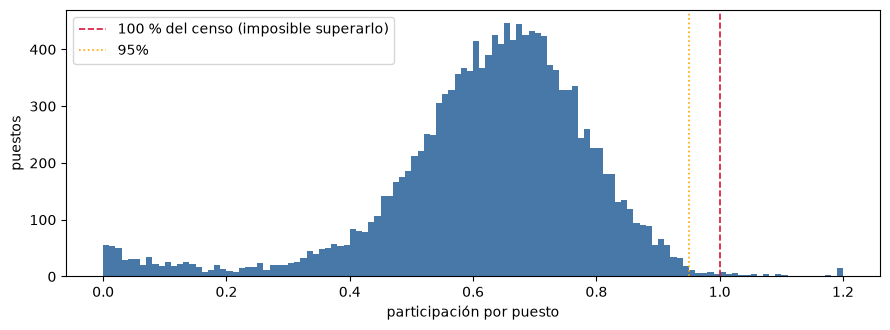

In [10]:
part = por_puesto.dropna(subset=["participacion"])
print(f"participación por puesto: mediana={part.participacion.median():.1%}  "
      f"p95={part.participacion.quantile(.95):.1%}  p99={part.participacion.quantile(.99):.1%}")

altos = part[part.participacion >= UMBRAL_ALTO].sort_values("participacion", ascending=False)
print(f"\npuestos con participación >= {UMBRAL_ALTO:.0%}: {len(altos):,} "
      f"({100*len(altos)/len(part):.3f}%)")
if len(altos):
    cols = ["departamento","municipio","nombre_puesto","votos","censo","participacion","mesas_con_votos"]
    print(altos[cols].head(20).to_string(index=False))
    altos.to_csv(SALIDA / "participacion_alta.csv", index=False)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.hist(part.participacion.clip(0, 1.2), bins=120, color="#4878a8")
ax.axvline(1.0, color="crimson", ls="--", lw=1.2, label="100 % del censo (imposible superarlo)")
ax.axvline(UMBRAL_ALTO, color="orange", ls=":", lw=1.2, label=f"{UMBRAL_ALTO:.0%}")
ax.set_xlabel("participación por puesto"); ax.set_ylabel("puestos"); ax.legend()
plt.tight_layout(); plt.show()

## 3 · Tasa base por departamento

Un hallazgo aislado no dice nada sin su tasa base. Si las anomalías se
concentran en un departamento, puede ser un problema de proceso local — o un
artefacto de cómo se registró el censo allí.

In [11]:
# tasa base por departamento
g = (por_puesto.groupby("departamento")
     .agg(puestos=("votos", "size"), votos=("votos", "sum"), censo=("censo", "sum"))
     .reset_index())

# nº de puestos que exceden el censo, por departamento (0 si no hay ninguno)
if len(excede):
    ex_dep = excede.groupby("departamento").size()
    g["excede"] = g.departamento.map(ex_dep).fillna(0).astype(int)
else:
    g["excede"] = 0

g["participacion"] = g.votos / g.censo
g["pct_excede"] = 100 * g.excede / g.puestos
g = g.sort_values("participacion", ascending=False)
print(g.to_string(index=False, float_format=lambda v: f"{v:,.3f}"))

print("\nLa participación varía mucho entre departamentos por razones legítimas")
print("(urbano/rural, censo desactualizado por migración). Lo que importa aquí no")
print("es que un departamento vote más, sino que algún puesto SUPERE su censo.")

departamento  puestos   votos   censo  excede  participacion  pct_excede
CUNDINAMARCA      684 1715010 2335305       7          0.734       1.023
       CAUCA      818  788558 1075975       4          0.733       0.489
    CASANARE      171  236380  328773       1          0.719       0.585
      BOYACA      398  741139 1039293       2          0.713       0.503
 BOGOTA D.C.     1083 4293148 6076599       0          0.707       0.000
      NARIÑO      941  859047 1225565      10          0.701       1.063
   SANTANDER      825 1284149 1861932       3          0.690       0.364
        META      289  582953  854033       2          0.683       0.692
       HUILA      268  620224  937739       1          0.661       0.373
     CAQUETA      152  212362  327418       0          0.649       0.000
    PUTUMAYO      121  169937  263450       0          0.645       0.000
      CALDAS      339  531856  828671       0          0.642       0.000
      TOLIMA      514  744399 1170701       3      

## 4 · Control: la 1ª vuelta

Las mismas mesas y el mismo censo, distinta elección. Si una anomalía aparece en
**ambas** vueltas es un problema estructural del puesto o del censo; si sólo en
la 2ª, es cualitativamente distinta.

In [12]:
f1 = mmv.localizar(MMV_1V)
esc1 = mmv.cargar_escrutinio(f1["escrutinio"])
dv1  = mmv.cargar_divipol(f1["divipol"]) if "divipol" in f1 else dv
ind1 = mmv.cargar_indicadores(f1["indicadores"]) if "indicadores" in f1 else ind

f1_filas = []
for k, votos in esc1.items():
    p = dv1.get((k[0], k[1], k[2], k[3]))
    if not p:
        continue
    f1_filas.append({"dep":k[0],"muni":k[1],"zona":k[2],"puesto":k[3],"mesa":k[4],
                     "votos":sum(votos.values()),
                     "tope_legal":ind1.get(p["indicador"],("",0))[1],
                     "censo_puesto":p["pot_hombres"]+p["pot_mujeres"],
                     "departamento":p["departamento"]})
d1 = pd.DataFrame(f1_filas)
v1 = d1[d1.votos > d1.tope_legal]
pp1 = d1.groupby(["dep","muni","zona","puesto"]).agg(
    votos=("votos","sum"), censo=("censo_puesto","first")).reset_index()
ex1 = pp1[pp1.votos > pp1.censo]

print(f"{'':22s} {'1a vuelta':>12s} {'2a vuelta':>12s}")
print(f"{'mesas':22s} {len(d1):>12,} {len(df):>12,}")
print(f"{'superan tope legal':22s} {len(v1):>12,} {len(viola_tope):>12,}")
print(f"{'puestos > censo':22s} {len(ex1):>12,} {len(excede):>12,}")
print(f"{'participación global':22s} {d1.votos.sum()/pp1.censo.sum():>11.1%} {df.votos.sum()/por_puesto.censo.sum():>11.1%}")

                          1a vuelta    2a vuelta
mesas                       122,020      122,020
superan tope legal                0            0
puestos > censo                  33           57
participación global         56.7%       62.3%


## 5 · Conclusión

Rellená esto con lo que salga y avisame para incorporarlo al informe
consolidado (E6):

- ¿Alguna mesa supera su **tope legal**? → chequeo duro A
- ¿Algún puesto supera su **censo**? → chequeo duro B
- ¿Cuántos votos representa, **contra el margen de 251.854**?
- ¿Se comporta igual la 1ª vuelta? → si sí, es estructural, no de esta elección

### Si sale limpio

Es un **resultado publicable**, no un fracaso: *"se verificó la restricción
física sobre 122.020 mesas y 14.438 puestos, con dos fuentes de censo
independientes que coinciden, y se cumple"*. Eso es exactamente lo que da
credibilidad cuando el proyecto sí señale algo.

### Si aparece algo

Antes de darle cualquier peso:

1. Comprobar que el puesto no sea de los especiales (indicador ≠ 1): los de
   censo y exterior tienen reglas distintas.
2. Comprobar si pasa también en 1ª vuelta.
3. Ir al **acta escaneada** de esas mesas — puede ser un error del dato oficial,
   no de la votación.

⚠️ Como siempre: esto **no dictamina fraude**. Marca, cuantifica y documenta.